# Naïve Bayes Classifier

**Dataset:** Digits (sklearn built-in)  
**Task:** Multiclass classification — handwritten digits 0–9

---

## Overview

Naïve Bayes is a **probabilistic classifier** grounded in Bayes' theorem. It is "naïve" because it assumes all features are **conditionally independent** given the class label — a strong assumption that often doesn't hold in practice, yet the classifier frequently performs surprisingly well.

### Bayes' Theorem

$$P(y \mid \mathbf{x}) = \frac{P(\mathbf{x} \mid y) \, P(y)}{P(\mathbf{x})}$$

- $P(y)$ — **prior**: frequency of class $y$ in training data  
- $P(\mathbf{x} \mid y)$ — **likelihood**: probability of features given class $y$  
- $P(y \mid \mathbf{x})$ — **posterior**: what we want to classify with

Since $P(\mathbf{x})$ is constant across classes, we compute:

$$\hat{y} = \underset{y}{\arg\max} \; P(y) \prod_{j=1}^{p} P(x_j \mid y)$$

### Gaussian Naïve Bayes

When features are continuous, we model each $P(x_j \mid y)$ as a Gaussian:

$$P(x_j \mid y) = \frac{1}{\sqrt{2\pi \sigma_{jy}^2}} \exp\!\left(-\frac{(x_j - \mu_{jy})^2}{2\sigma_{jy}^2}\right)$$

Training just requires computing the class-conditional means $\mu_{jy}$ and variances $\sigma_{jy}^2$.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(42)
plt.rcParams['font.size'] = 12

## 2. Load and Explore the Digits Dataset

In [2]:
data = load_digits()
X, y = data.data, data.target

print(f"Samples: {X.shape[0]}, Features (pixels): {X.shape[1]}")
print(f"Image size: 8×8")
print(f"Digit classes: {np.unique(y)}")
print(f"Class distribution: {np.bincount(y)}")

Samples: 1797, Features (pixels): 64
Image size: 8×8
Digit classes: [0 1 2 3 4 5 6 7 8 9]
Class distribution: [178 182 177 183 181 182 181 179 174 180]


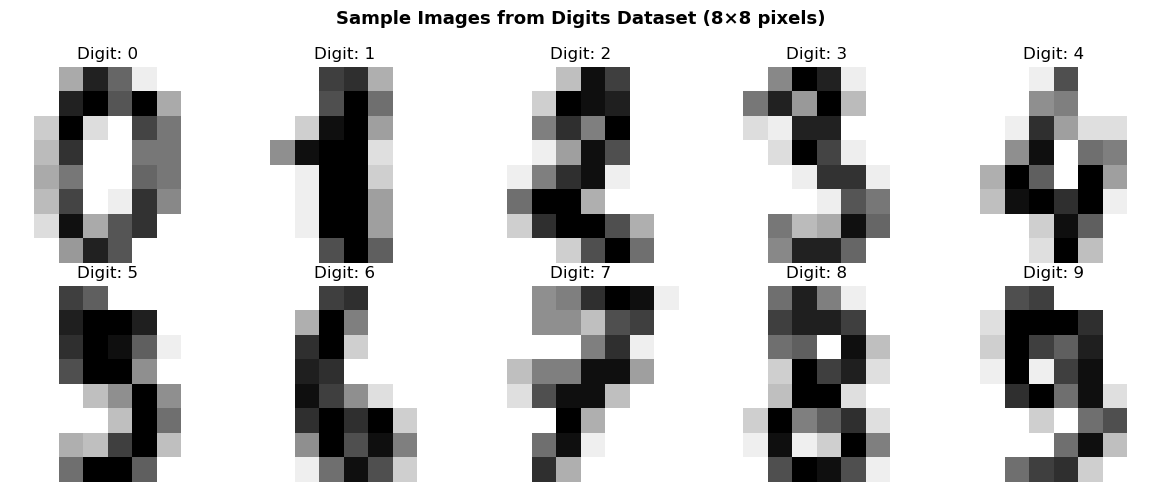

In [3]:
# Visualize one sample per digit
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for digit in range(10):
    idx = np.where(y == digit)[0][0]
    axes[digit].imshow(X[idx].reshape(8, 8), cmap='gray_r')
    axes[digit].set_title(f'Digit: {digit}', fontsize=12)
    axes[digit].axis('off')

plt.suptitle('Sample Images from Digits Dataset (8×8 pixels)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Gaussian Naïve Bayes from Scratch

We implement GNB manually to understand the mechanics.

In [4]:
class GaussianNaiveBayesScratch:
    """Gaussian Naïve Bayes classifier."""

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.priors_  = {}
        self.means_   = {}
        self.vars_    = {}

        for c in self.classes_:
            Xc = X[y == c]
            self.priors_[c] = Xc.shape[0] / X.shape[0]
            self.means_[c]  = Xc.mean(axis=0)
            self.vars_[c]   = Xc.var(axis=0) + 1e-9  # add small value for numerical stability

        return self

    def _log_likelihood(self, x, c):
        mu, sigma2 = self.means_[c], self.vars_[c]
        return -0.5 * np.sum(np.log(2 * np.pi * sigma2) + (x - mu)**2 / sigma2)

    def predict(self, X):
        preds = []
        for x in X:
            log_posteriors = {
                c: np.log(self.priors_[c]) + self._log_likelihood(x, c)
                for c in self.classes_
            }
            preds.append(max(log_posteriors, key=log_posteriors.get))
        return np.array(preds)

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

## 4. Train and Evaluate

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Our from-scratch implementation
gnb_scratch = GaussianNaiveBayesScratch()
gnb_scratch.fit(X_train, y_train)

# sklearn for comparison
gnb_sklearn = GaussianNB()
gnb_sklearn.fit(X_train, y_train)

print(f"Scratch GNB   — Train: {gnb_scratch.accuracy(X_train, y_train):.4f} | Test: {gnb_scratch.accuracy(X_test, y_test):.4f}")
print(f"sklearn GNB   — Train: {gnb_sklearn.score(X_train, y_train):.4f} | Test: {gnb_sklearn.score(X_test, y_test):.4f}")

Scratch GNB   — Train: 0.8024 | Test: 0.7722
sklearn GNB   — Train: 0.8372 | Test: 0.8111


## 5. Confusion Matrix

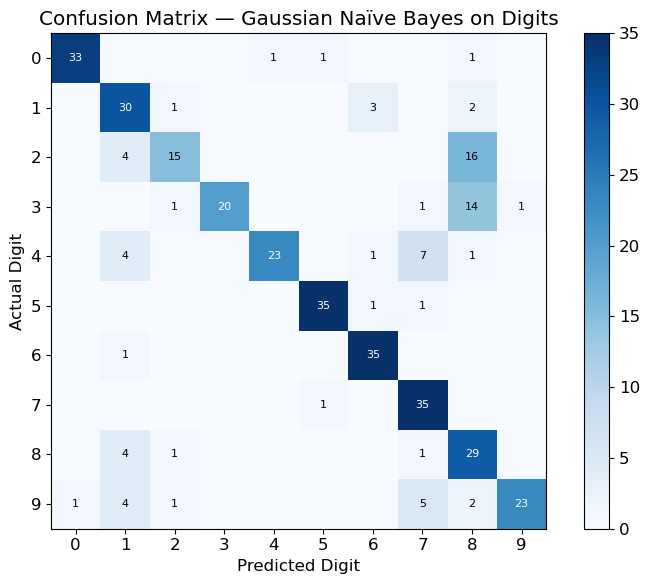

In [6]:
y_pred = gnb_scratch.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im)
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel('Predicted Digit'); ax.set_ylabel('Actual Digit')
ax.set_title('Confusion Matrix — Gaussian Naïve Bayes on Digits')
for i in range(10):
    for j in range(10):
        if cm[i,j] > 0:
            ax.text(j, i, cm[i,j], ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=8)
plt.tight_layout()
plt.show()

## 6. Visualize Class-Conditional Means

The mean pixel intensities for each digit class — this is what Naïve Bayes learns.

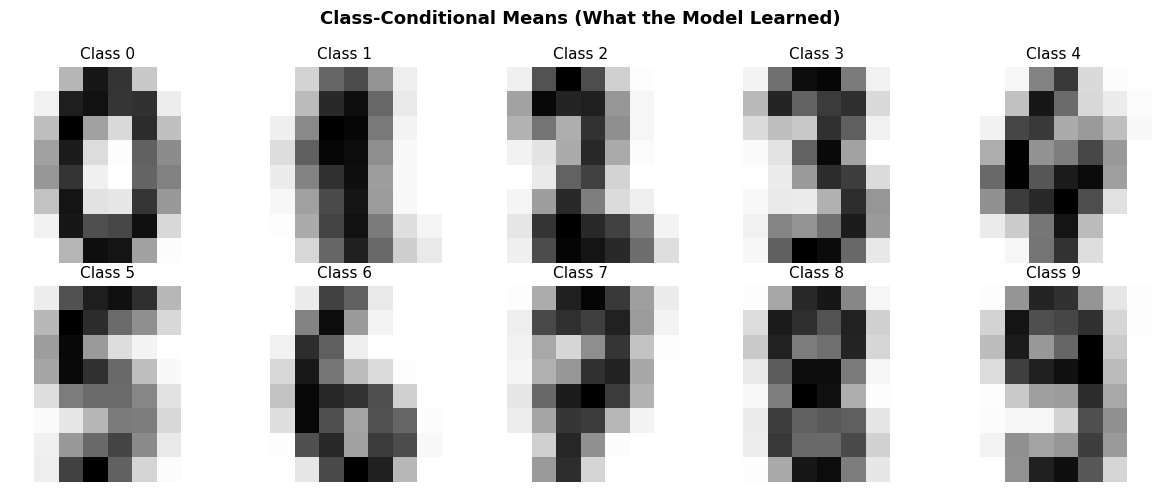

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for digit in range(10):
    mean_img = gnb_scratch.means_[digit].reshape(8, 8)
    axes[digit].imshow(mean_img, cmap='gray_r')
    axes[digit].set_title(f'Class {digit}', fontsize=11)
    axes[digit].axis('off')

plt.suptitle('Class-Conditional Means (What the Model Learned)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Compare Naïve Bayes Variants

In [8]:
# Bernoulli NB (binary features) and Multinomial NB (counts/frequencies)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

nb_models = {
    'Gaussian NB (scratch)': (gnb_scratch, X_train, X_test, y_train, y_test),
    'Gaussian NB (sklearn)': (GaussianNB(), X_train, X_test, y_train, y_test),
    'Bernoulli NB':          (BernoulliNB(binarize=8.0), X_train, X_test, y_train, y_test),
    'Multinomial NB':        (MultinomialNB(), X_train_scaled, X_test_scaled, y_train, y_test),
}

for name, (model, Xtr, Xte, ytr, yte) in nb_models.items():
    if hasattr(model, 'fit') and not hasattr(model, 'classes_'):
        model.fit(Xtr, ytr)
    if hasattr(model, 'score'):
        test_acc = model.score(Xte, yte)
    else:
        test_acc = model.accuracy(Xte, yte)
    print(f"{name:25s}: Test Accuracy = {test_acc:.4f}")

Gaussian NB (scratch)    : Test Accuracy = 0.7722
Gaussian NB (sklearn)    : Test Accuracy = 0.8111
Bernoulli NB             : Test Accuracy = 0.8861
Multinomial NB           : Test Accuracy = 0.8889


## 8. Summary

### Key Takeaways

- Naïve Bayes uses **Bayes' theorem** with the conditional independence assumption to compute class probabilities.
- **Gaussian NB** models continuous features as Gaussian distributions — it only needs to estimate per-class means and variances.
- Training is extremely **fast**: $O(n \cdot p)$, as it just computes class-conditional statistics.
- Despite its strong (often incorrect) independence assumption, Naïve Bayes often achieves **competitive accuracy** especially on text and image classification.
- **Bernoulli NB** works with binary features; **Multinomial NB** works with frequency counts (common in text classification).
- The visualized class means show that the model essentially learns a "prototype" image for each digit.